In [ ]:
# Group Members: Navpreet Kloy, Aidan Gonzales, Mauricio Ferreyra-Ruiz (Monday & Wednesday)

Dataset:  https://www.kaggle.com/datasets/hosan707/job-salary-prediction-dataset


In [ ]:
import xgboost as xgb  # XGBoost library for gradient boosting
import pandas as pd
from sklearn.model_selection import train_test_split  # Split data into train/test
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder  # Converts words to numbers
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  #  Check how well the model did


In [ ]:
# load dataset
df = pd.read_csv("job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [ ]:
# dataset overview
df.info()
print('\nDataset shape (samples, features):', df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB

Dataset shape (samples, features): (250000, 10)


In [ ]:
# Use LabelEncoder to convert text to numbers
# Create a separate encoder for each column
# (Each column has its own set of categories)
encoder_job_title = LabelEncoder()
encoder_education_level = LabelEncoder()
encoder_industry    = LabelEncoder()
encoder_company_size  = LabelEncoder()
encoder_location  = LabelEncoder()
encoder_remote_work = LabelEncoder()



# fit_transform: learn the categories AND convert to numbers
df["job_title"]   = encoder_job_title.fit_transform(df["job_title"])
df["education_level"]  = encoder_education_level.fit_transform(df["education_level"])
df["industry"]      = encoder_industry.fit_transform(df["industry"])
df["company_size"]      = encoder_company_size.fit_transform(df["company_size"])
df["location"]      = encoder_location .fit_transform(df["location"])
df["remote_work"]      = encoder_remote_work.fit_transform(df["remote_work"])

df


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,0,10,0,2,4,2,3,0,2,109413
1,5,5,0,17,9,3,0,1,0,93764
2,8,18,4,4,6,2,6,1,1,148123
3,2,19,4,13,7,2,1,2,0,189123
4,10,15,0,7,5,1,7,2,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,11,17,4,2,9,0,3,1,1,127791
249996,8,20,4,7,9,4,5,1,2,154593
249997,2,1,0,12,7,0,3,2,0,75988
249998,6,0,2,2,0,3,7,0,5,90467


In [ ]:
# define the X features and y (output label)
X = df.drop("salary", axis=1) # Input features
y = df["salary"]                 # Output label

In [ ]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,   # Same split every run (reproducible)
)

In [ ]:
# TRAINING XGBOOST REGRESSOR

# Initialize XGBoost Regressor
# Note: We use XGBRegressor (not Classifier) for predicting continuous values
model = xgb.XGBRegressor(
    max_depth=4,           # Maximum depth of trees
    n_estimators=100,      # Number of boosting rounds (trees)
    learning_rate=0.1,     # Step size for updating predictions
    objective='reg:squarederror',  # Minimize squared error (standard for regression)
    random_state=42,       # For reproducibility
    subsample=0.8,         # Use 80% of data for each tree (prevents overfitting)
    colsample_bytree=0.8   # Use 80% of features for each tree
)

print("Model parameters:")
print(f"  - Max tree depth: {model.max_depth}")
print(f"  - Number of trees: {model.n_estimators}")
print(f"  - Learning rate: {model.learning_rate}")
print(f"  - Subsample ratio: {model.subsample}")

Model parameters:
  - Max tree depth: 4
  - Number of trees: 100
  - Learning rate: 0.1
  - Subsample ratio: 0.8


In [ ]:
# Train the model
print("\nTraining in progress...")
model.fit(X_train, y_train, verbose=False)  # verbose=False to reduce output
print("✓ Training complete!")


Training in progress...
✓ Training complete!


In [ ]:
# Predict on test set
y_test_pred = model.predict(X_test)

In [ ]:
# Evaluate the model

mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 46904560.0
R-squared: 0.9662523865699768
Root Mean Squared Error: 6848.690385759894
Mean Absolute Error: 5449.369140625


/tmp/ipykernel_6367/2488152197.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importance, y=sorted_features, palette="viridis")


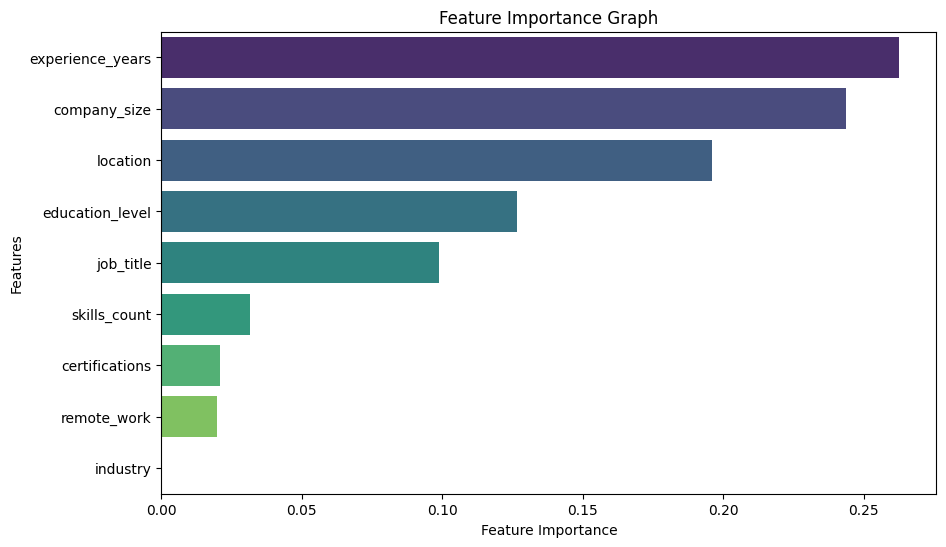

In [ ]:
# Feature Importance Implementation
feature_names = X.columns.tolist()
feature_importance = model.feature_importances_

# Sorting by Importance (High)
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importance = feature_importance[sorted_idx]

# Plotting the Feature Importance Graph
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importance, y=sorted_features, palette="viridis")
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance Graph')
plt.show()

####Summary:

For this job salary prediction dataset we built an Extreme Gradient Boosting algorithm to predict employee salaries based on nine different characteristics such as, job title, years of experience, education level, industry, company size, location, remote work status, skills, and certifications. This dataset consisted of approxiamtely 250,000 salary inputs gathered from various individuals. The way Extreme Gradiant Boosting works in this scenario was by building a series of decision trees sequentially, in which each new tree corrected its errors from the previous tree. This ultimately resulted in a higher accurate combined prediction.

This model on this specific dataset acheived an R^2 score of approximately 0.97 on the testing set. This describes how there is about 97% of variation in the salaries alone, with an average prediction error of about $6,500. The feature importance chart sheds light on how experience years and skills count were the stronges factors of salary, then followed by their job title, and certificiations. These findings can ultimately help Human Resource departments set competitive salary ranges and identify which employee attributes influence their overall salary.